In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit.library.generalized_gates import LinearFunction
from qiskit.transpiler import CouplingMap

from qiskit_gym.envs import LinearFunctionGym, LinearFunctionNoisyGym
from qiskit_gym.rl import RLSynthesis, PPOConfig, BasicPolicyConfig

In [2]:
N_QUBITS = 7
NOISY_EDGES = [(1, 4), (3, 4)]

MIAMI_EDGES_UNI   = [(0,1),(1,2),(0,3),(1,4),(2,5),(3,4),(4,5),(4,6)]
MIAMI_EDGES_BIDIR = MIAMI_EDGES_UNI + [(b, a) for (a, b) in MIAMI_EDGES_UNI]

miami_cmap = CouplingMap(MIAMI_EDGES_BIDIR)

print(f"Qubits      : {N_QUBITS}")
print(f"Edges       : {MIAMI_EDGES_UNI}")
print(f"Noisy edges : {NOISY_EDGES}  (noise rate -0.9 each)")
print(f"Clean edges : all others  (noise rate 0.0)")

Qubits      : 7
Edges       : [(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5), (4, 6)]
Noisy edges : [(1, 4), (3, 4)]  (noise rate -0.9 each)
Clean edges : all others  (noise rate 0.0)


In [4]:
noise_map = {e: -0.9 for e in NOISY_EDGES}

env_noisy = LinearFunctionNoisyGym.from_coupling_map(
    miami_cmap,
    basis_gates=["CX", "SWAP"],
    noise_map=noise_map,
    default_noise_rate=0.0,
)

env_noiseless = LinearFunctionGym.from_coupling_map(
    miami_cmap,
    basis_gates=["CX", "SWAP"],
)

print("NoisyRL     gateset size:", len(env_noisy.config['gateset']))
print("NoiselessRL gateset size:", len(env_noiseless.config['gateset']))

NoisyRL     gateset size: 32
NoiselessRL gateset size: 32


In [5]:
ppo_cfg = PPOConfig(
    num_episodes=256,
    diff_max=256,
    checkpoint_freq=999999,
)

NUM_ITERATIONS = 1000

In [ ]:
print("Training NoiselessRL")
noiseless_rl = RLSynthesis(env_noiseless, ppo_cfg, BasicPolicyConfig())
noiseless_rl.learn(num_iterations=NUM_ITERATIONS, tb_path=None)
print("Done.")

Training NoiselessRL ...


2026-03-30 14:10:41.257 | INFO     | twisterl.rl.algorithm:learn:177 - (1/0) {'successes': {'ppo_deterministic': 0.05000000074505806, 'ppo_10': 0.3799999952316284}, 'rewards': {'ppo_deterministic': -0.4326171875, 'ppo_10': 0.06367187201976776}, 'difficulty': 1, 'success': 0.05000000074505806, 'reward': -0.4326171875} | {'to_rust': 0.00586925, 'eval_ppo_deterministic': 0.002050709, 'eval_ppo_10': 0.009346209, 'collect': 0.004405042, 'data_to_torch': 0.034666333, 'train': 0.2928865, 'total': 0.349371875}
2026-03-30 14:10:41.328 | INFO     | twisterl.rl.algorithm:learn:177 - (1/1) {'successes': {'ppo_deterministic': 0.029999999329447746, 'ppo_10': 0.3100000023841858}, 'rewards': {'ppo_deterministic': -0.46269530057907104, 'ppo_10': -0.04160156100988388}, 'difficulty': 1, 'success': 0.029999999329447746, 'reward': -0.46269530057907104} | {'to_rust': 0.005680208, 'eval_ppo_deterministic': 0.001414334, 'eval_ppo_10': 0.010979958, 'collect': 0.005267292, 'data_to_torch': 0.004785, 'train': 0.

Done.


In [ ]:
print("Training NoisyRL")
noisy_rl = RLSynthesis(env_noisy, ppo_cfg, BasicPolicyConfig())
noisy_rl.learn(num_iterations=NUM_ITERATIONS, tb_path=None)
print("Done.")

2026-03-30 14:15:16.480 | INFO     | twisterl.rl.algorithm:learn:177 - (1/0) {'successes': {'ppo_deterministic': 0.0, 'ppo_10': 0.38999998569488525}, 'rewards': {'ppo_deterministic': -0.5078125, 'ppo_10': 0.00671093724668026}, 'difficulty': 1, 'success': 0.0, 'reward': -0.5078125} | {'to_rust': 0.005298791, 'eval_ppo_deterministic': 0.003131833, 'eval_ppo_10': 0.009791292, 'collect': 0.004659625, 'data_to_torch': 0.004956792, 'train': 0.034989084, 'total': 0.062978375}
2026-03-30 14:15:16.538 | INFO     | twisterl.rl.algorithm:learn:177 - (1/1) {'successes': {'ppo_deterministic': 0.019999999552965164, 'ppo_10': 0.36000001430511475}, 'rewards': {'ppo_deterministic': -0.47773438692092896, 'ppo_10': -0.020406246185302734}, 'difficulty': 1, 'success': 0.019999999552965164, 'reward': -0.47773438692092896} | {'to_rust': 0.005037875, 'eval_ppo_deterministic': 0.001598667, 'eval_ppo_10': 0.008314333, 'collect': 0.005099416, 'data_to_torch': 0.004808334, 'train': 0.032678834, 'total': 0.0576475

Training NoisyRL ...


2026-03-30 14:15:16.608 | INFO     | twisterl.rl.algorithm:learn:177 - (1/2) {'successes': {'ppo_deterministic': 0.05000000074505806, 'ppo_10': 0.3799999952316284}, 'rewards': {'ppo_deterministic': -0.4326171875, 'ppo_10': 0.03667187690734863}, 'difficulty': 1, 'success': 0.05000000074505806, 'reward': -0.4326171875} | {'to_rust': 0.005061709, 'eval_ppo_deterministic': 0.001540209, 'eval_ppo_10': 0.011545333, 'collect': 0.008252333, 'data_to_torch': 0.005052375, 'train': 0.038259625, 'total': 0.069823084}
2026-03-30 14:15:16.676 | INFO     | twisterl.rl.algorithm:learn:177 - (1/3) {'successes': {'ppo_deterministic': 0.019999999552965164, 'ppo_10': 0.3199999928474426}, 'rewards': {'ppo_deterministic': -0.47773438692092896, 'ppo_10': -0.08956251293420792}, 'difficulty': 1, 'success': 0.019999999552965164, 'reward': -0.47773438692092896} | {'to_rust': 0.005091708, 'eval_ppo_deterministic': 0.001429833, 'eval_ppo_10': 0.009766334, 'collect': 0.006012666, 'data_to_torch': 0.005720583, 'trai

Done.


In [9]:
def count_metrics(qc, noisy_edges):
    noisy_pairs = {frozenset(e) for e in noisy_edges}
    count_2q = 0
    count_noisy = 0
    for instr in qc.data:
        if instr.operation.num_qubits == 2:
            count_2q += 1
            qidx = frozenset(qc.find_bit(q).index for q in instr.qubits)
            if qidx in noisy_pairs:
                count_noisy += 1
    return count_2q, count_noisy

def verify_equivalence(input_qc, output_qc):
    return LinearFunction(input_qc) == LinearFunction(output_qc)

In [ ]:
NUM_SEARCHES = 5000

results = []

for i, (qc, size) in enumerate(zip(test_circuits, CIRCUIT_SIZES)):
    print(f"\nCircuit {i+1} ({size} gates)")

    out_nl = noiseless_rl.synth(qc, num_searches=NUM_SEARCHES, num_mcts_searches=0, deterministic=False)
    out_ny = noisy_rl.synth(qc, num_searches=NUM_SEARCHES, num_mcts_searches=0, deterministic=False)

    if out_nl is None:
        print(f" NoiselessRL failed.")
        nl_2q, nl_noisy, nl_ok = None, None, False
    else:
        nl_2q, nl_noisy = count_metrics(out_nl, NOISY_EDGES)
        nl_ok = verify_equivalence(qc, out_nl)
        print(f"NoiselessRL  2Q ops: {nl_2q:3d}  noisy ops: {nl_noisy:3d}  equiv: {nl_ok}")

    if out_ny is None:
        print(f"  NoisyRL failed.")
        ny_2q, ny_noisy, ny_ok = None, None, False
    else:
        ny_2q, ny_noisy = count_metrics(out_ny, NOISY_EDGES)
        ny_ok = verify_equivalence(qc, out_ny)
        print(f" NoisyRL 2Q ops: {ny_2q:3d}  noisy ops: {ny_noisy:3d}  equiv: {ny_ok}")

    results.append({
        "circuit": i + 1,
        "input_gates": size,
        "nl_2q": nl_2q, "nl_noisy": nl_noisy,
        "ny_2q": ny_2q, "ny_noisy": ny_noisy,
        "nl_ok": nl_ok, "ny_ok": ny_ok,
    })


Circuit 1 (5 gates)
  NoiselessRL  2Q ops:   8  noisy ops:   1  equiv: True
  NoisyRL      2Q ops:  10  noisy ops:   0  equiv: True

Circuit 2 (8 gates)
  NoiselessRL  2Q ops:  12  noisy ops:   2  equiv: True
  NoisyRL      2Q ops:  44  noisy ops:   0  equiv: True

Circuit 3 (12 gates)
  NoiselessRL  2Q ops:  21  noisy ops:   5  equiv: True
  NoisyRL      2Q ops: 109  noisy ops:   0  equiv: True

Circuit 4 (15 gates)
  NoiselessRL  2Q ops:  19  noisy ops:   3  equiv: True
  NoisyRL      2Q ops:  52  noisy ops:   1  equiv: True

Circuit 5 (20 gates)
  NoiselessRL  2Q ops:  15  noisy ops:   6  equiv: True
  NoisyRL      2Q ops:  20  noisy ops:   0  equiv: True


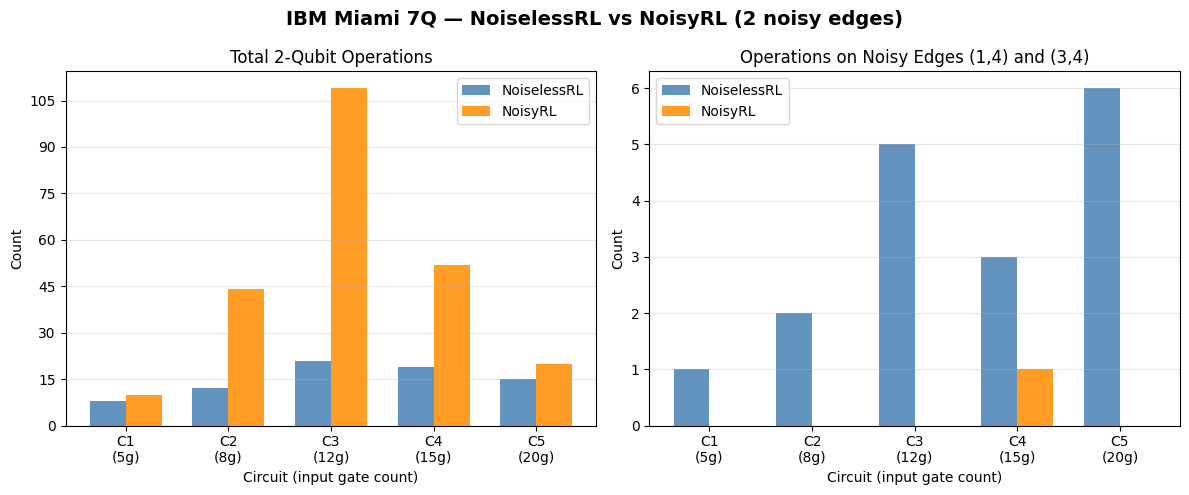

In [14]:
ok_results = [r for r in results if r['nl_2q'] is not None and r['ny_2q'] is not None]

if not ok_results:
    print("No circuits were successfully solved by both agents — skipping plot.")
    print("Try increasing NUM_ITERATIONS for training.")
else:
    labels   = [f"C{r['circuit']}\n({r['input_gates']}g)" for r in ok_results]
    nl_2q    = [r['nl_2q']    for r in ok_results]
    ny_2q    = [r['ny_2q']    for r in ok_results]
    nl_noisy = [r['nl_noisy'] for r in ok_results]
    ny_noisy = [r['ny_noisy'] for r in ok_results]

    x = np.arange(len(ok_results))
    w = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("IBM Miami 7Q — NoiselessRL vs NoisyRL (2 noisy edges)", fontsize=14, fontweight='bold')

    ax1.bar(x - w/2, nl_2q,   w, label='NoiselessRL', color='steelblue',  alpha=0.85)
    ax1.bar(x + w/2, ny_2q,   w, label='NoisyRL',     color='darkorange', alpha=0.85)
    ax1.set_title("Total 2-Qubit Operations")
    ax1.set_xlabel("Circuit (input gate count)")
    ax1.set_ylabel("Count")
    ax1.set_xticks(x); ax1.set_xticklabels(labels)
    ax1.legend()
    ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.grid(axis='y', alpha=0.3)

    ax2.bar(x - w/2, nl_noisy, w, label='NoiselessRL', color='steelblue',  alpha=0.85)
    ax2.bar(x + w/2, ny_noisy, w, label='NoisyRL',     color='darkorange', alpha=0.85)
    ax2.set_title("Operations on Noisy Edges (1,4) and (3,4)")
    ax2.set_xlabel("Circuit (input gate count)")
    ax2.set_ylabel("Count")
    ax2.set_xticks(x); ax2.set_xticklabels(labels)
    ax2.legend()
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('benchmark2_results.png')
    plt.show()